In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

## Data Preprocessing

### Training Image Preprocessing

In [2]:
# this is coming from : https://keras.io/api/data_loading/image/

training_set = tf.keras.utils.image_dataset_from_directory(
    "train", #directory name
    labels="inferred", # choose the subdir names as labels
    label_mode="categorical", 
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    verbose=True,
)

Found 70295 files belonging to 38 classes.


### Validation image preprocessing

In [11]:
# we will do the same for validation set

validation_set = tf.keras.utils.image_dataset_from_directory(
    "valid", #directory name
    labels="inferred", # choose the subdir names as labels
    label_mode="categorical", 
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    verbose=True,
)

validation_set

Found 17572 files belonging to 38 classes.


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>

In [13]:
for x, y in training_set:
    print(x, x.shape)
    print(y, y.shape)
    break

tf.Tensor(
[[[[  0.     0.     0.  ]
   [  0.     0.     0.  ]
   [  0.     0.     0.  ]
   ...
   [  0.     0.     0.  ]
   [  0.     0.     0.  ]
   [  0.     0.     0.  ]]

  [[  0.     0.     0.  ]
   [  0.     0.     0.  ]
   [  0.     0.     0.  ]
   ...
   [  0.     0.     0.  ]
   [  0.     0.     0.  ]
   [  0.     0.     0.  ]]

  [[  0.     0.     0.  ]
   [  0.     0.     0.  ]
   [  0.     0.     0.  ]
   ...
   [  0.     0.     0.  ]
   [  0.     0.     0.  ]
   [  0.     0.     0.  ]]

  ...

  [[  0.     0.     0.  ]
   [  0.     0.     0.  ]
   [  0.     0.     0.  ]
   ...
   [  0.     0.     0.  ]
   [  0.     0.     0.  ]
   [  0.     0.     0.  ]]

  [[  0.     0.     0.  ]
   [  0.     0.     0.  ]
   [  0.     0.     0.  ]
   ...
   [  0.     0.     0.  ]
   [  0.     0.     0.  ]
   [  0.     0.     0.  ]]

  [[  0.     0.     0.  ]
   [  0.     0.     0.  ]
   [  0.     0.     0.  ]
   ...
   [  0.     0.     0.  ]
   [  0.     0.     0.  ]
   [  0.     0.     

## lets build the model

#### To avoid overshooting
- Choose a very small learning rate default is 0.001 and change to 0.0001
- there might be a chance for underfitting, so increase the number of neurons
- Add more convulational layer to extract more feature from images there may be a possibilty that model unabal to capture relevent fearure or model is cofusing due to lack of feature so feed with more feature

In [57]:
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout
from tensorflow.keras.models import Sequential

In [58]:
model = Sequential()

### Building Convulation Layer

 - filer
 - kernel_size 
 - padding 
 - activation
 - input_shape

In [59]:
model.add(Conv2D(filters=32, kernel_size=3, padding='same', activation= 'relu', input_shape= [128, 128, 3]))
# adding hidden layers
model.add(Conv2D(filters=32, kernel_size=3, activation= 'relu'))
# adding hidden layers

model.add(MaxPool2D(pool_size=2, strides=2))

/opt/homebrew/Caskroom/miniconda/base/envs/env1/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Why need the layer again below?
 this is part of 

In [60]:
model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation= 'relu'))
model.add(Conv2D(filters=64, kernel_size=3, activation= 'relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

In [61]:
model.add(Conv2D(filters=128, kernel_size=3, padding='same', activation= 'relu'))
model.add(Conv2D(filters=128, kernel_size=3, activation= 'relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

In [62]:
model.add(Conv2D(filters=256, kernel_size=3, padding='same', activation= 'relu'))
model.add(Conv2D(filters=256, kernel_size=3, activation= 'relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

In [63]:
model.add(Conv2D(filters=512, kernel_size=3, padding='same', activation= 'relu'))
model.add(Conv2D(filters=512, kernel_size=3, activation= 'relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

In [67]:
model.add(Dropout(0.25)) # to avoid overfitting

In [68]:
model.add(Flatten())

In [69]:
model.add(Dense(units=1500, activation='relu')) #units -> number of neurons

In [70]:
model.add(Dropout(0.4))

In [71]:
#Output Layer
model.add(Dense(units=38, activation='softmax'))

### Compiling

In [73]:
model.compile(optimizer= tf.keras.optimizers.Adam(learning_rate= 0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

In [74]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_31 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1500)           │     3,073,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1500)           │     2,251,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 38)             │        57,038 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,094,262 (38.51 MB)

 Trainable params: 10,094,262 (38.51 MB)

 Non-trainable params: 0 (0.00 B)

## Model Training


In [75]:
training_history = model.fit(x= training_set, validation_data=validation_set, epochs=10)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1082s 492ms/step - accuracy: 0.5559 - loss: 1.5202 - val_accuracy: 0.8190 - val_loss: 0.5885
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 3857s 2s/step - accuracy: 0.8516 - loss: 0.4742 - val_accuracy: 0.9028 - val_loss: 0.3061
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 2400s 1s/step - accuracy: 0.9111 - loss: 0.2784 - val_accuracy: 0.9285 - val_loss: 0.2274
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 2876s 1s/step - accuracy: 0.9370 - loss: 0.1953 - val_accuracy: 0.9277 - val_loss: 0.2354
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1039s 473ms/step - accuracy: 0.9517 - loss: 0.1483 - val_accuracy: 0.9523 - val_loss: 0.1546
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 994s 452ms/step - accuracy: 0.9629 - loss: 0.1145 - val_accuracy: 0.9564 - val_loss: 0.1396
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1193s 543ms/step - accuracy: 0.9702 - loss: 0.0932 - val_accuracy: 0.9563 - val_loss: 0.1413
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1421s 647ms/step - accu

## Model Evaluation on training set

In [77]:
train_loss, train_accuracy = model.evaluate(training_set)

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 265s 121ms/step - accuracy: 0.9917 - loss: 0.0259


In [78]:
print(train_loss, train_accuracy)

0.025902705267071724 0.9917348027229309


In [80]:
val_loss, val_acc = model.evaluate(validation_set)

550/550 ━━━━━━━━━━━━━━━━━━━━ 69s 125ms/step - accuracy: 0.9677 - loss: 0.1201


## Saving Model

In [81]:
model.save("trained_model.h5")

In [ ]:
training_history.history


{'accuracy': [0.5559428334236145,
  0.8515968322753906,
  0.9110747575759888,
  0.9369513988494873,
  0.9516893029212952,
  0.962913453578949,
  0.97022545337677,
  0.9753040671348572,
  0.9778362512588501,
  0.9808236956596375],
 'loss': [1.5202240943908691,
  0.47421586513519287,
  0.2784275710582733,
  0.1953098475933075,
  0.14828331768512726,
  0.1144675686955452,
  0.09317602962255478,
  0.07764515280723572,
  0.06914869695901871,
  0.06036271154880524],
 'val_accuracy': [0.8190302848815918,
  0.9027999043464661,
  0.9285226464271545,
  0.9276690483093262,
  0.9523105025291443,
  0.956407904624939,
  0.9562941193580627,
  0.9624402523040771,
  0.9643751382827759,
  0.9677327275276184],
 'val_loss': [0.5884689688682556,
  0.30612894892692566,
  0.22740571200847626,
  0.23537035286426544,
  0.15459178388118744,
  0.13955806195735931,
  0.14132215082645416,
  0.12740173935890198,
  0.12435155361890793,
  0.12012602388858795]}

#### Saving History in json format

In [ ]:
import json
with open('training_history.json', 'w') as f:
    json.dump(training_history.history, f)
    

#### Accuracy visualizations

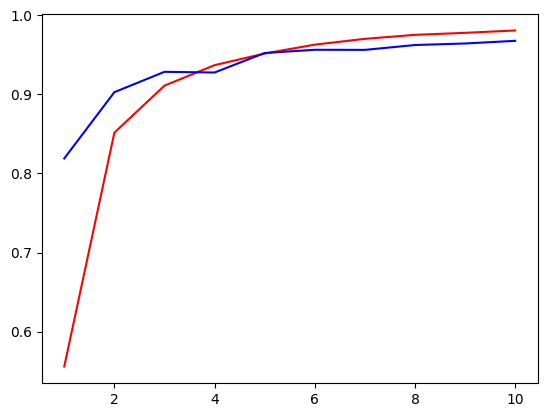

In [ ]:
epchs = [i for i in range(1, 11)]
plt.plot(epchs, training_history.history['accuracy'], 'red', label='Training Accuracy')
plt.plot(epchs, training_history.history['val_accuracy'], 'blue', label='Validation Accuracy')


## Some other metrics for model evaluation



In [12]:
class_names = validation_set.class_names
class_names

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [7]:
from tensorflow import keras
model = keras.models.load_model('trained_model.h5')

In [9]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_31 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1500)           │     3,073,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1500)           │     2,251,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 38)             │        57,038 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,094,264 (38.51 MB)

 Trainable params: 10,094,262 (38.51 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [49]:
class_names = validation_set.class_names
print(class_names)

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Sp

## Test set prediction


In [37]:
test_set = tf.keras.utils.image_dataset_from_directory(
    "valid", #directory name
    labels="inferred", # choose the subdir names as labels
    label_mode="categorical", 
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    verbose=True,
)

Found 17572 files belonging to 38 classes.


In [ ]:
y_pred = model.predict(test_set)
y_pred

550/550 ━━━━━━━━━━━━━━━━━━━━ 65s 117ms/step


array([[1.00000000e+00, 1.77877180e-09, 6.01467227e-13, ...,
        6.74028618e-18, 1.84480451e-15, 2.59137092e-14],
       [9.99985099e-01, 7.16932527e-06, 6.96582969e-09, ...,
        6.48011419e-12, 1.47438922e-10, 8.12990841e-10],
       [1.00000000e+00, 9.45152290e-11, 1.77423126e-13, ...,
        2.89265189e-19, 3.40139421e-16, 3.81093980e-14],
       ...,
       [4.75537942e-11, 1.78828697e-12, 9.25872090e-09, ...,
        4.23138573e-11, 3.60813185e-10, 9.99999762e-01],
       [1.56631987e-08, 2.00578304e-10, 1.24936562e-07, ...,
        2.80547390e-08, 2.78616454e-08, 9.99979436e-01],
       [1.08655890e-12, 1.31550573e-13, 1.16987565e-11, ...,
        4.41135253e-11, 2.75509532e-10, 9.99998808e-01]],
      shape=(17572, 38), dtype=float32)

In [30]:
pred_categories = tf.argmax(y_pred, axis=1)
pred_categories

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], shape=(17572,))>

In [31]:
true_categories = tf.concat([y for x,y in test_set], axis=0)
true_categories

2025-11-08 12:13:46.908013: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


<tf.Tensor: shape=(17572, 38), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], shape=(17572, 38), dtype=float32)>

In [32]:
Y_true = tf.argmax(true_categories, axis=1)
Y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], shape=(17572,))>

In [40]:
from sklearn.metrics import classification_report
cfr = classification_report(Y_true, pred_categories, target_names=class_names)
print(cfr)

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.94      0.94      0.94       504
                                 Apple___Black_rot       1.00      0.98      0.99       497
                          Apple___Cedar_apple_rust       0.98      0.97      0.98       440
                                   Apple___healthy       0.99      0.95      0.97       502
                               Blueberry___healthy       0.95      0.98      0.97       454
          Cherry_(including_sour)___Powdery_mildew       0.96      0.99      0.97       421
                 Cherry_(including_sour)___healthy       1.00      0.98      0.99       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.95      0.91      0.93       410
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       477
               Corn_(maize)___Northern_Leaf_Blight       0.93      0.97      0.

In [45]:
from sklearn.metrics import confusion_matrix


cm = confusion_matrix(Y_true, pred_categories)
cm.shape

(38, 38)

<Axes: >

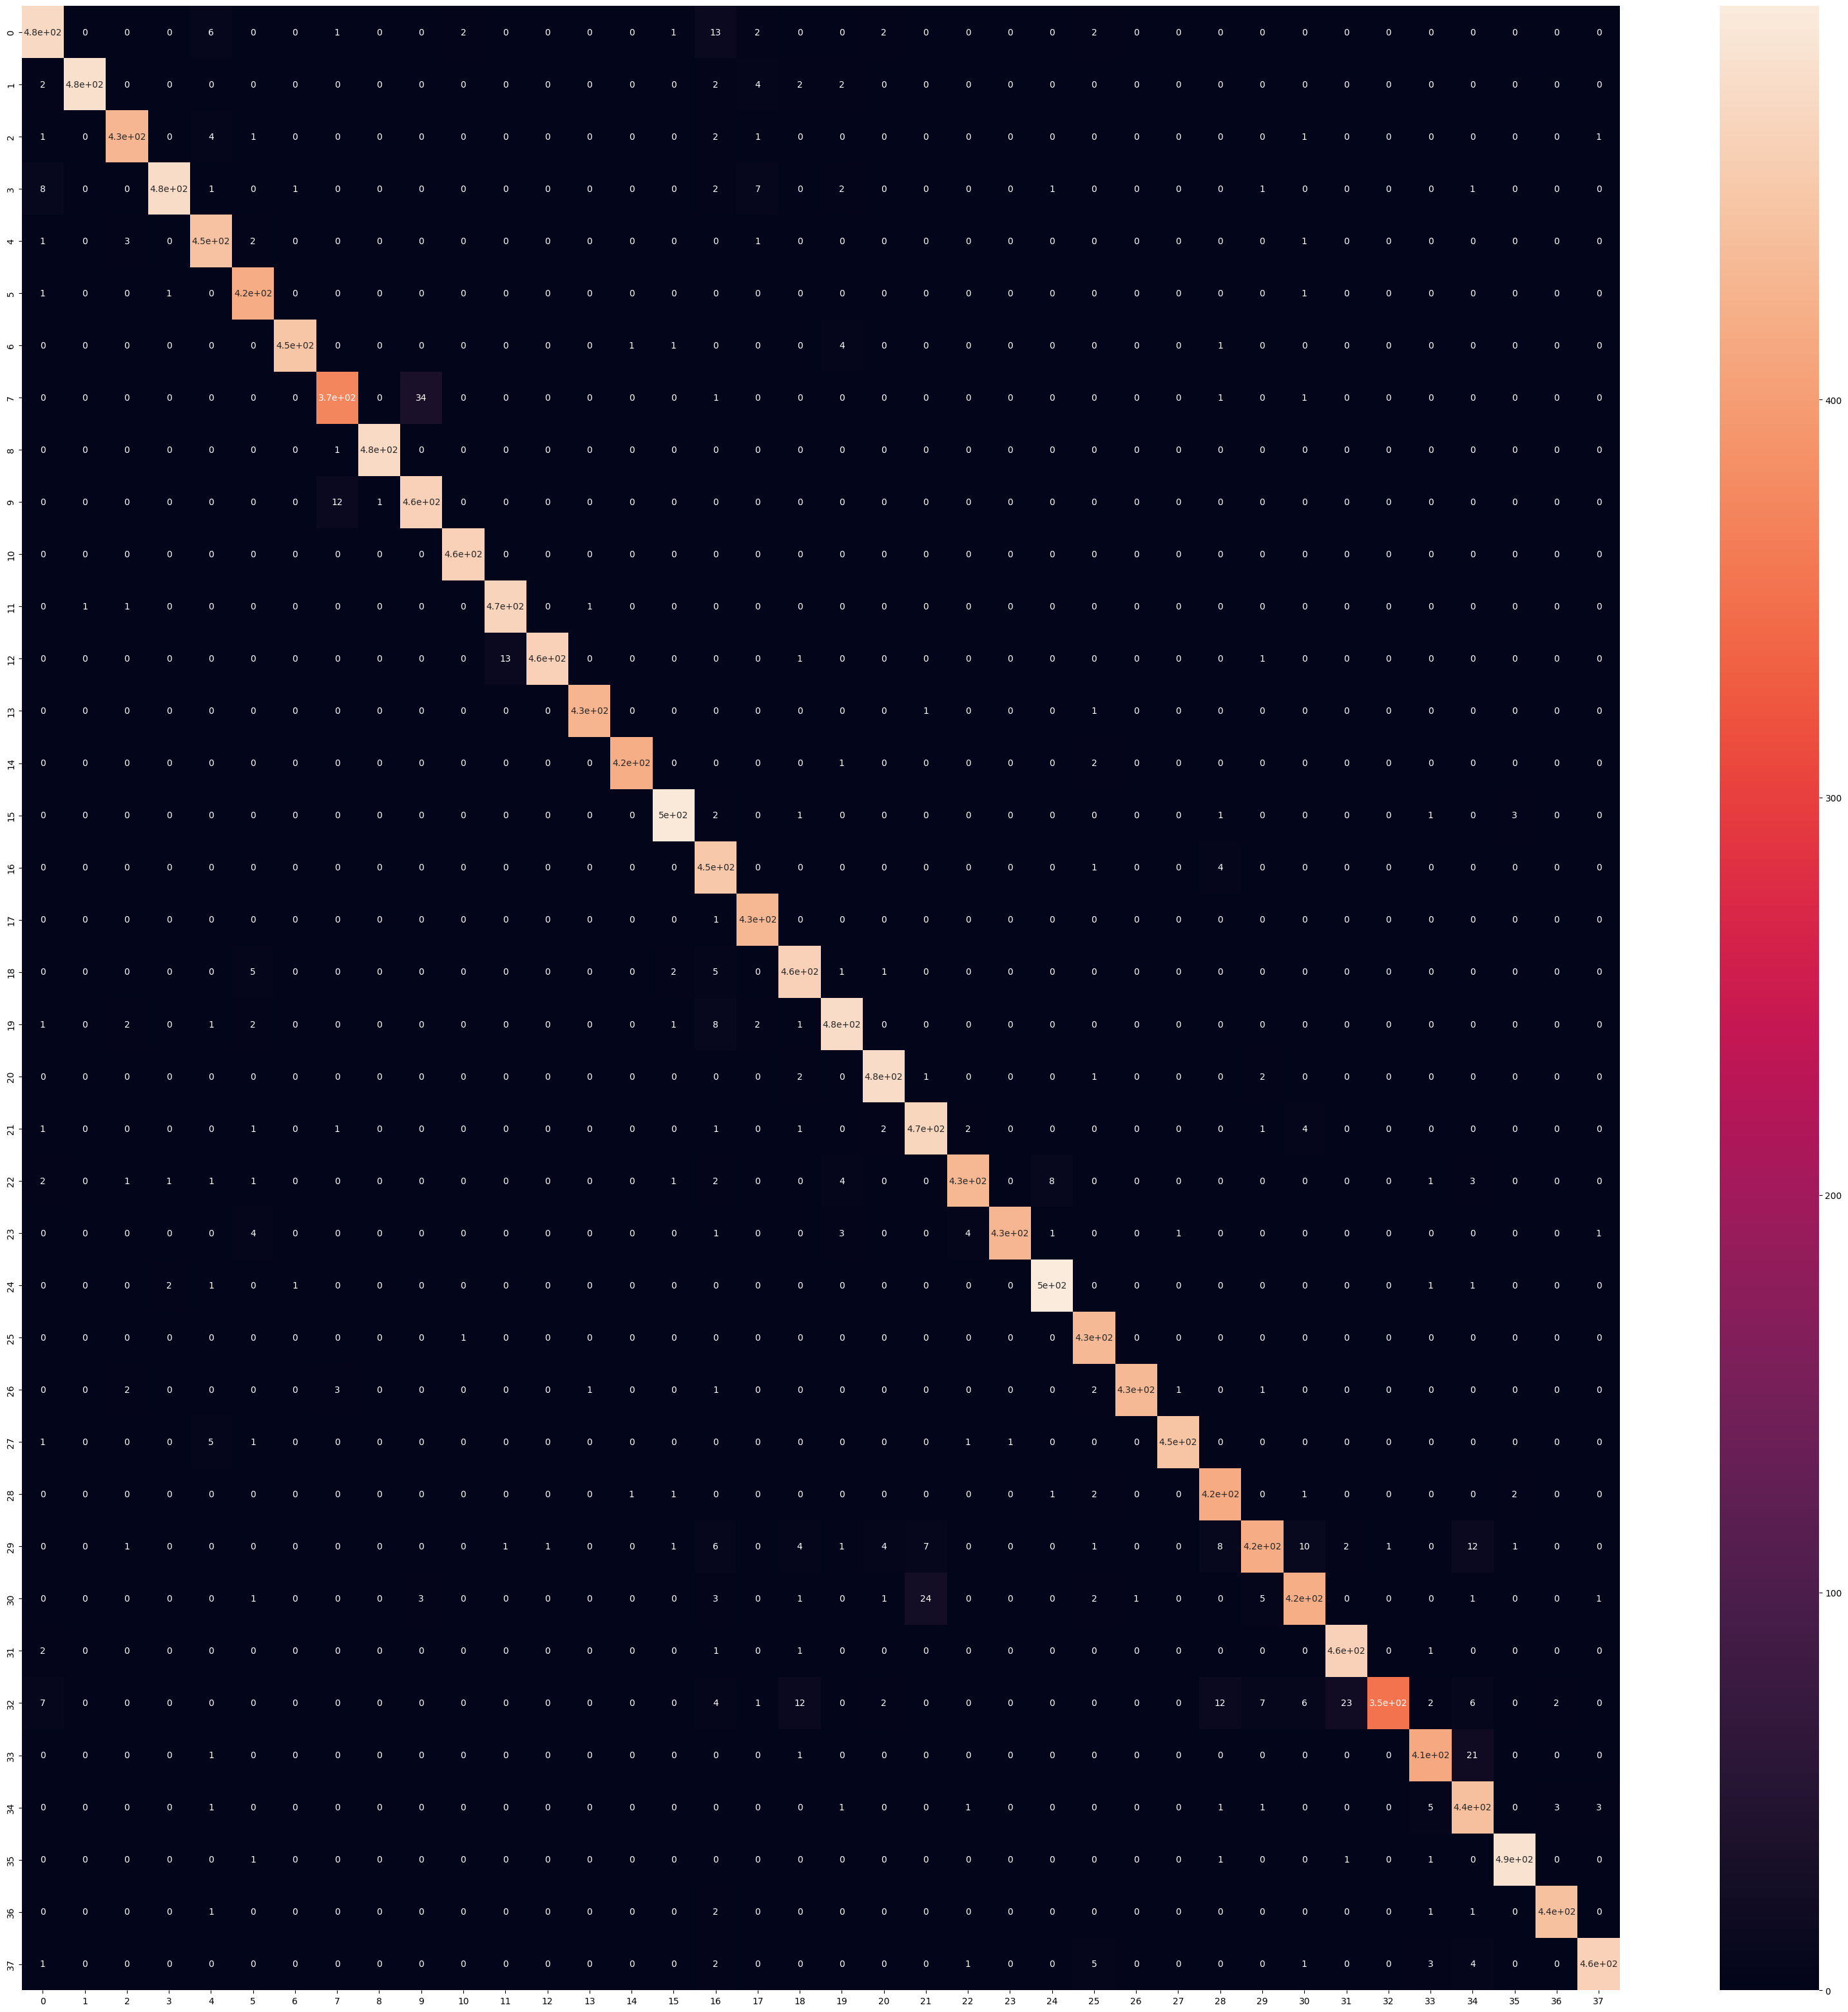

In [48]:
import seaborn as sns
plt.figure(figsize= (40,40))
sns.heatmap(cm, annot= True)